<a href="https://colab.research.google.com/github/tuhaovan917-ship-it/thuc_hanh_deeplearning/blob/main/buoi_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Khảo sát và load dataset

In [1]:
import pandas as pd

url = 'https://github.com/huynhhoc/DataAnalystDeepLearning/raw/refs/heads/main/Data/dulieuxettuyendaihoc.csv'
df = pd.read_csv(url)
# Hiển thị 5 dòng dữ liệu đầu tiên
df.head()

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A


In [2]:
# 1. Kiểm tra kích thước bộ dữ liệu
print('Kích thước bảng dữ liệu mẫu:', df.shape, end='\n\n')

# 2. Xem thông tin chi tiết kiểu dữ liệu của các cột
# Hàm .info() sẽ liệt kê tên từng cột, số lượng cột, số lượng ô có dữ liệu và kiểu dữ liệu
print('Thông tin kiểu dữ liệu:')
df.info()
print('\n')

# Kiểm tra xem dữ liệu có bị thiếu không (trống) ở cột nào không
# Hàm .isnull() sẽ kiểm tra từng ô, kết hợp với .sum() để cộng tổng số ô trống ở từng cột
print('--- Số lượng giá trị thiếu ở mỗi cột ---')
print(df.isnull().sum(), end='\n\n')

Kích thước bảng dữ liệu mẫu: (100, 56)

Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null    float64
 2   L1      100 non-null    float64
 3   H1      100 non-null    float64
 4   S1      100 non-null    float64
 5   V1      100 non-null    float64
 6   X1      100 non-null    float64
 7   D1      100 non-null    float64
 8   N1      100 non-null    float64
 9   T2      100 non-null    float64
 10  L2      100 non-null    float64
 11  H2      100 non-null    float64
 12  S2      100 non-null    float64
 13  V2      100 non-null    float64
 14  X2      100 non-null    float64
 15  D2      100 non-null    float64
 16  N2      100 non-null    float64
 17  T3      100 non-null    float64
 18  L3      100 non-null    float64
 19  H3      100 non-null    float64
 20  S3      100 n

## Tiền xử lý dữ liệu

In [3]:
# Xóa các cột dư thừa
df.drop(columns=['STT', 'GT', 'DT', 'KV'], axis=1, inplace=True)

# Các cột còn lại sau khi xóa
print('Các cột còn lại sau khi xóa: ', df.columns, end='\n\n')

Các cột còn lại sau khi xóa:  Index(['T1', 'L1', 'H1', 'S1', 'V1', 'X1', 'D1', 'N1', 'T2', 'L2', 'H2', 'S2',
       'V2', 'X2', 'D2', 'N2', 'T3', 'L3', 'H3', 'S3', 'V3', 'X3', 'D3', 'N3',
       'T4', 'L4', 'H4', 'S4', 'V4', 'X4', 'D4', 'N4', 'T5', 'L5', 'H5', 'S5',
       'V5', 'X5', 'D5', 'N5', 'T6', 'L6', 'H6', 'S6', 'V6', 'X6', 'D6', 'N6',
       'DH1', 'DH2', 'DH3', 'KT'],
      dtype='object')



In [4]:
# pd.get_dummies giúp chuyển cột dạng chữ sang cột mới tương ứng dạng số chứa số 0 hoặc 1
df_sach = pd.get_dummies(df, columns=['KT'])

# In thử 5 dòng đầu bảng mới
df_sach.head()

,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,D6,N6,DH1,DH2,DH3,KT_A,KT_A1,KT_B,KT_C,KT_D1
0,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,8.9,...,7.6,5.9,3.25,3.25,4.50,False,True,False,False,False
1,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,5.4,...,6.1,4.4,6.00,4.00,3.50,False,False,False,True,False
2,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,4.9,...,8.1,4.6,5.00,6.75,4.00,False,False,False,True,False
3,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,6.2,...,7.3,7.4,4.25,4.25,5.25,False,False,False,False,True
4,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,5.5,...,7.5,7.2,4.25,4.50,5.00,True,False,False,False,False


## Chia tập train, val và test

In [5]:
# Tạo ma trận X (input)
X = df_sach.drop(columns=['DH1', 'DH2', 'DH3'])

# Tạo ma trận Y (output)
Y = df_sach[['DH1', 'DH2', 'DH3']]

# In thử kích thước của X và Y
print('Kích thước ma trận X: ', X.shape)
print('Kích thước ma trận Y: ', Y.shape)

Kích thước ma trận X:  (100, 53)
Kích thước ma trận Y:  (100, 3)


In [6]:
# import hàm chia dữ liệu từ thư viện scikit-learn
from sklearn.model_selection import train_test_split

# ==========================================
# LẦN CHIA 1: Tách thành 80% Train và 20% tập tạm thời (Tập này sẽ gồm cả Val và Test)
# ==========================================
# test_size=0.2 nghĩa là giữ lại 20% dữ liệu cho tập tạm thời
X_train, X_temporary, Y_train, Y_temporary = train_test_split(X, Y, test_size=0.2, random_state=42) # 42, cố định

# ==========================================
# LẦN CHIA 2: Lấy 20% tập tạm thời băm đôi (50-50) để ra 10% Val và 10% Test
# ==========================================
# test_size=0.5 của 20% sẽ bằng đúng 10% tổng dữ liệu ban đầu
X_val, X_test, Y_val, Y_test = train_test_split(X_temporary, Y_temporary, test_size=0.5, random_state=42)

# ==========================================
# KIỂM TRA KẾT QUẢ: In ra kích thước của cả 3 tập để kiểm tra dòng/cột
# ==========================================
print('--- KÍCH THƯỚC ĐẦU VÀO (INPUT X) ---')
print('Tập train X:', X_train.shape)
print('Tập validation X:', X_val.shape)
print('Tập test X:', X_test.shape)

print('--- KÍCH THƯỚC ĐẦU RA (OUTPUT Y) ---')
print('Tập train Y:', Y_train.shape)
print('Tập validation Y:', Y_val.shape)
print('Tập test Y:', Y_test.shape)

--- KÍCH THƯỚC ĐẦU VÀO (INPUT X) ---
Tập train X: (80, 53)
Tập validation X: (10, 53)
Tập test X: (10, 53)
--- KÍCH THƯỚC ĐẦU RA (OUTPUT Y) ---
Tập train Y: (80, 3)
Tập validation Y: (10, 3)
Tập test Y: (10, 3)


In [7]:
# Chú thích: Import công cụ chuẩn hóa dữ liệu Z-score (StandardScaler)
from sklearn.preprocessing import StandardScaler

# Khởi tạo một bộ scaler rỗng
scaler = StandardScaler()

# Bước 1: Vừa HỌC thông số trên tập Train, vừa biến đổi tập Train luôn
X_train_scaled = scaler.fit_transform(X_train)

# Bước 2: Chỉ biến đổi (transform) tập Val và tập Test dựa trên những gì đã học từ Train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Kiểm tra thử dữ liệu sau khi chuẩn hóa dòng đầu tiên của tập Train
print("Dòng đầu tiên sau khi chuẩn hóa:\n", X_train_scaled[0])

Dòng đầu tiên sau khi chuẩn hóa:
 [ 1.17527734  0.82858447  0.49024873  0.34168092  1.02126015 -2.05206065
 -0.56039399  0.66596078  1.30982752  0.9800805   0.14669279 -0.93045554
  0.95976457 -0.54000395 -0.35497325  0.99131194  1.48352609  1.51617044
  0.02910511 -1.11862619  0.17275579 -0.28742412 -0.33280897  0.10207885
  1.45347355  0.73294574  0.51261878 -1.17506232 -0.00893603  0.01001493
  0.3025145   0.45931256  1.8752092   1.66245024  1.09588331  1.86785187
  0.95235202 -0.98130896  1.08649345  0.85817284  1.93417332  1.4226605
  0.0173509   1.04158068  0.83742646 -0.17168226  0.22419753  0.48206611
 -0.92761259  4.35889894 -0.30966177 -0.4404882  -0.55809982]


# Mô hình

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input

In [9]:
tf.keras.utils.set_random_seed(42) # Khóa mọi sự ngẫu nhiên của TensorFlow/Keras lại bằng con số 42

model = Sequential()

# Định nghĩa cổng vào riêng biệt ở đây
model.add(Input(shape=(53,)))
# Lớp ẩn 1: Cần khai báo input_shape ở đây để mở cổng dữ liệu
model.add(Dense(64, activation='relu'))
# Lớp ẩn 2: Không cần shape gì cả
model.add(Dense(32, activation='relu'))
# Lớp đầu ra: Chỉ cần chỉ định số lượng 3 nodes
model.add(Dense(3, activation='linear'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,635 (22.01 KB)

 Trainable params: 5,635 (22.01 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Huấn luyện mô hình

In [11]:
# Huấn luyện mô hình và lưu lịch sử học tập vào biến history
history = model.fit(
    X_train_scaled,          # Đầu vào tập Train (đã chuẩn hóa)
    Y_train,                 # Đầu ra tập Train (điểm thật)
    validation_data=(X_val_scaled, Y_val), # Ép mô hình "thi thử" trên tập Val sau mỗi vòng
    epochs=100,              # Cho mô hình học đi học lại toàn bộ dữ liệu 100 lần
    batch_size=16,           # Cứ bốc ngẫu nhiên 16 học sinh vào tính toán một lần
    verbose=1                # Bật chế độ hiển thị tiến trình học tập theo từng vòng
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 20.6832 - mae: 4.3449 - val_loss: 18.7817 - val_mae: 4.0897
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 18.3517 - mae: 4.0605 - val_loss: 17.0734 - val_mae: 3.8716
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 16.3701 - mae: 3.7957 - val_loss: 15.5291 - val_mae: 3.6555
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 14.5072 - mae: 3.5238 - val_loss: 13.9634 - val_mae: 3.4116
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 12.6884 - mae: 3.2400 - val_loss: 12.3682 - val_mae: 3.1384
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 10.8980 - mae: 2.9471 - val_loss: 10.8119 - val_mae: 2.8496
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 9.2011 - mae: 2.6530 - val_loss: 9.3705 - val_mae: 2.6085
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 7.6692 - mae: 2.3709 - val_loss: 8.0939 - val_mae: 2.4124
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 6

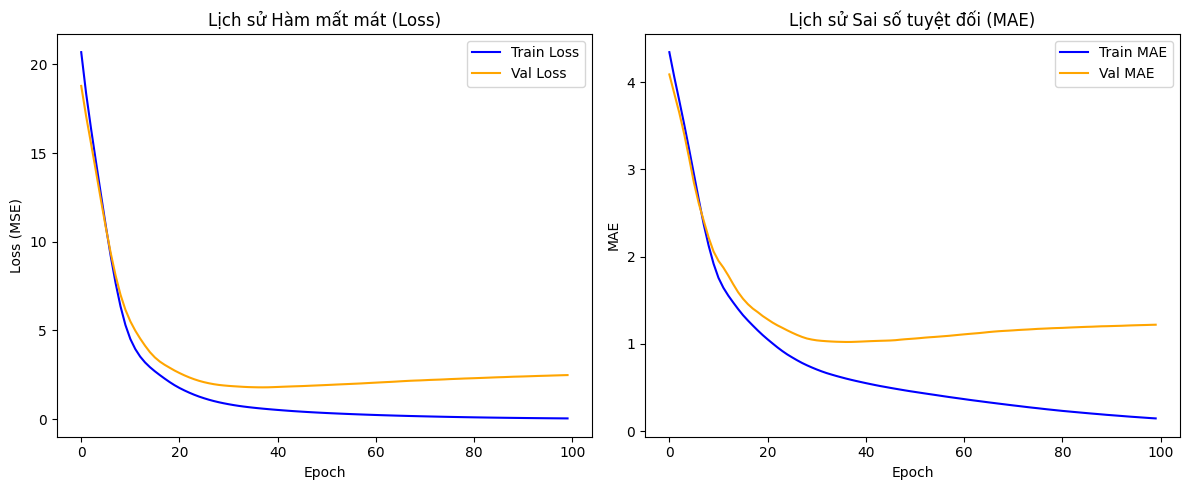

In [12]:
import matplotlib.pyplot as plt

# 1. Vẽ biểu đồ Loss (Hàm mất mát)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Lịch sử Hàm mất mát (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# 2. Vẽ biểu đồ MAE (Sai số tuyệt đối)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', color='blue')
plt.plot(history.history['val_mae'], label='Val MAE', color='orange')
plt.title('Lịch sử Sai số tuyệt đối (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
test_results = model.evaluate(X_test_scaled, Y_test)
print(f"\n=> Sai số thực tế cuối cùng (MAE) trên tập TEST giấu kín: {test_results[1]:.4f} điểm.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.1837 - mae: 1.2259

=> Sai số thực tế cuối cùng (MAE) trên tập TEST giấu kín: 1.2259 điểm.


# Mô hình 2

## Thêm lớp Dropout

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input

In [15]:
tf.keras.utils.set_random_seed(42) # Khóa mọi sự ngẫu nhiên của TensorFlow/Keras lại bằng con số 42

model_v2 = Sequential()

# Cổng vào tách riêng
model_v2.add(Input(shape=(53,)))
# Lớp ẩn 1 (64 nodes) + tắt ngẫu nhiên 20% node ở mỗi vòng
model_v2.add(Dense(64, activation='relu'))
model_v2.add(Dropout(0.2))

# Lớp ẩn 2 (32 nodes) + tắt ngẫu nhiên 20% node
model_v2.add(Dense(32, activation='relu'))
model_v2.add(Dropout(0.2))

# Lớp đầu ra (3 nodes)
model_v2.add(Dense(3))

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,635 (22.01 KB)

 Trainable params: 5,635 (22.01 KB)

 Non-trainable params: 0 (0.00 B)

## Early Stopping

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# Khai báo bộ giám sát Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', # Theo dõi sai số trên tập Validation
    patience=10,        # Nếu quá 10 vòng mà Val Loss không giảm thêm thì DỪNG
    restore_best_weights=True # Tự động lấy lại trọng số ở vòng tốt nhất để dùng
)

In [17]:
model_v2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [18]:
history_v2 = model_v2.fit(
    X_train_scaled, Y_train,
    validation_data=(X_val_scaled, Y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop], # Thêm dòng này vào nè bạn!
    verbose=1
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 21.6405 - mae: 4.4155 - val_loss: 19.8750 - val_mae: 4.2484
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 19.1546 - mae: 4.1483 - val_loss: 18.1681 - val_mae: 4.0573
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.7067 - mae: 3.9656 - val_loss: 16.5506 - val_mae: 3.8672
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 15.1219 - mae: 3.6486 - val_loss: 14.9345 - val_mae: 3.6633
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 13.6013 - mae: 3.4005 - val_loss: 13.2479 - val_mae: 3.4331
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 12.0678 - mae: 3.1750 - val_loss: 11.5165 - val_mae: 3.1741
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 11.0487 - mae: 3.0050 - val_loss: 9.7641 - val_mae: 2.8791
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.3875 - mae: 2.6859 - val_loss: 8.1081 - val_mae: 2.5595
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7

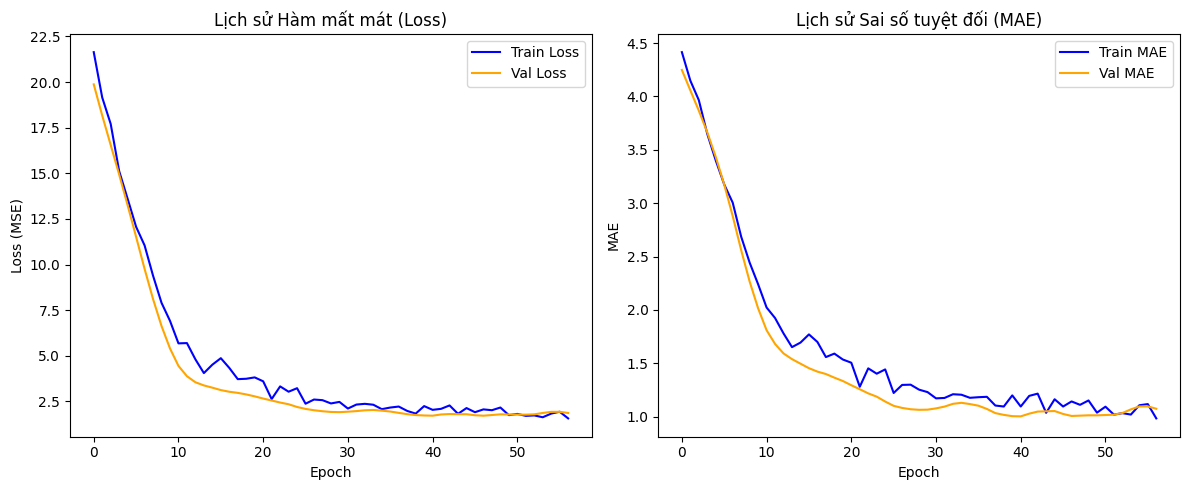

In [19]:
import matplotlib.pyplot as plt

# 1. Vẽ biểu đồ Loss (Hàm mất mát)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v2.history['loss'], label='Train Loss', color='blue')
plt.plot(history_v2.history['val_loss'], label='Val Loss', color='orange')
plt.title('Lịch sử Hàm mất mát (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# 2. Vẽ biểu đồ MAE (Sai số tuyệt đối)
plt.subplot(1, 2, 2)
plt.plot(history_v2.history['mae'], label='Train MAE', color='blue')
plt.plot(history_v2.history['val_mae'], label='Val MAE', color='orange')
plt.title('Lịch sử Sai số tuyệt đối (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
test_results = model_v2.evaluate(X_test_scaled, Y_test)
print(f"\n=> Sai số thực tế cuối cùng (MAE) trên tập TEST giấu kín: {test_results[1]:.4f} điểm.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.6069 - mae: 1.0150

=> Sai số thực tế cuối cùng (MAE) trên tập TEST giấu kín: 1.0150 điểm.


# Chạy thử nghiệm dự đoán thực tế

In [21]:
import numpy as np

# 1. Bốc đại học sinh đầu tiên trong tập Test để làm mẫu
hoc_sinh_mau = X_test_scaled[0:1]

# 2. Đưa vào mô hình V1 (Cơ bản) để dự đoán điểm 3 môn DH1, DH2, DH3
diem_du_doan = model.predict(hoc_sinh_mau)

# 3. In kết quả của Mô hình V1
print("="*20 + " MÔ HÌNH V1 (CƠ BẢN) " + "="*20)
print(f"Điểm AI dự đoán (DH1, DH2, DH3): {np.round(diem_du_doan[0], 2)}")
print(f"Điểm THỰC TẾ của học sinh này : {Y_test.iloc[0].values}")
print("="*61 + "\n")

# 4. Đưa vào mô hình V2 (Nâng cao) để dự đoán điểm 3 môn DH1, DH2, DH3
diem_du_doan_v2 = model_v2.predict(hoc_sinh_mau)

# 5. In kết quả của Mô hình V2
print("="*19 + " MÔ HÌNH V2 (NÂNG CAO) " + "="*19)
print(f"Điểm AI dự đoán (DH1, DH2, DH3): {np.round(diem_du_doan_v2[0], 2)}")
print(f"Điểm THỰC TẾ của học sinh này : {Y_test.iloc[0].values}")
print("="*61)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
==================== MÔ HÌNH V1 (CƠ BẢN) ====================
Điểm AI dự đoán (DH1, DH2, DH3): [3.7  5.19 4.65]
Điểm THỰC TẾ của học sinh này : [1.75 4.75 6.  ]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
=================== MÔ HÌNH V2 (NÂNG CAO) ===================
Điểm AI dự đoán (DH1, DH2, DH3): [4.81 4.58 4.78]
Điểm THỰC TẾ của học sinh này : [1.75 4.75 6.  ]


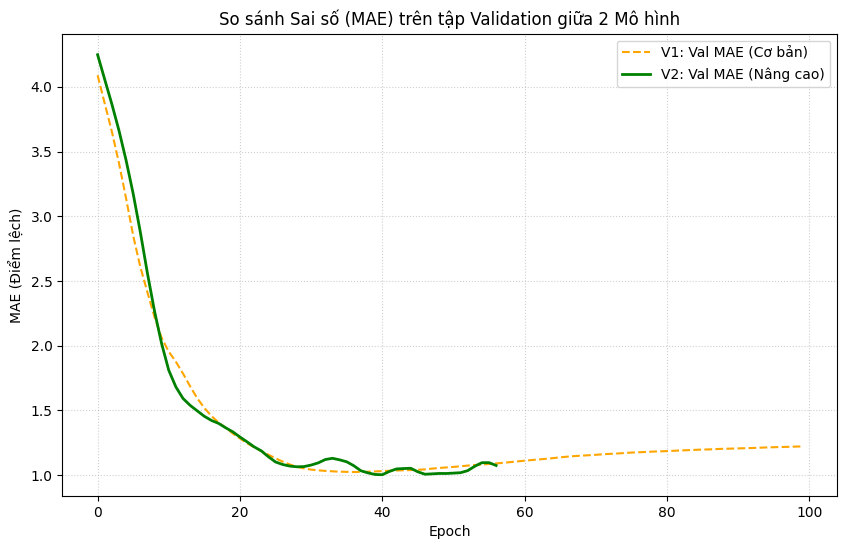


TIÊU CHÍ SO SÁNH          | MÔ HÌNH V1 | MÔ HÌNH V2
--------------------------------------------------
Số Epoch thực chạy        | 100 vòng   | 57 vòng   
Sai số TEST (MAE)         | 1.2259     | 1.0150    
--> Nhận xét: Mô hình V2 tốt hơn V1, giảm được 0.2109 điểm sai số nhờ Dropout và Early Stopping!


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. VẼ BIỂU ĐỒ SO SÁNH QUÁ TRÌNH HỌC (MAE)
# ==========================================
plt.figure(figsize=(10, 6))

# Đường cong của Mô hình V1 (Cơ bản)
plt.plot(history.history['val_mae'], label='V1: Val MAE (Cơ bản)', color='orange', linestyle='--')

# Đường cong của Mô hình V2 (Nâng cao - Dropout + Early Stopping)
plt.plot(history_v2.history['val_mae'], label='V2: Val MAE (Nâng cao)', color='green', linewidth=2)

plt.title('So sánh Sai số (MAE) trên tập Validation giữa 2 Mô hình')
plt.xlabel('Epoch')
plt.ylabel('MAE (Điểm lệch)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 2. ĐÁNH GIÁ VÀ IN BẢNG SO SÁNH TRÊN TẬP TEST
# ==========================================
results_v1 = model.evaluate(X_test_scaled, Y_test, verbose=0)
results_v2 = model_v2.evaluate(X_test_scaled, Y_test, verbose=0)

print("\n" + "="*50)
print(f"{'TIÊU CHÍ SO SÁNH':<25} | {'MÔ HÌNH V1':<10} | {'MÔ HÌNH V2':<10}")
print("-"*50)
print(f"{'Số Epoch thực chạy':<25} | {'100 vòng':<10} | {f'{len(history_v2.history['loss'])} vòng':<10}")
print(f"{'Sai số TEST (MAE)':<25} | {results_v1[1]:<10.4f} | {results_v2[1]:<10.4f}")
print("="*50)

if results_v2[1] < results_v1[1]:
    print(f"--> Nhận xét: Mô hình V2 tốt hơn V1, giảm được {results_v1[1] - results_v2[1]:.4f} điểm sai số nhờ Dropout và Early Stopping!")
else:
    print("--> Nhận xét: Hai mô hình có kết quả tương đương nhau.")